# **Real-Time Emotion Detection from Text Using NLP**

# Project Summary

This project builds a simple emotion detection system that classifies text into emotions such as joy, sadness, anger, fear, love, and surprise.

The project uses TF-IDF to convert text into numerical features, then trains two classification models: Naive Bayes and Logistic Regression. The models are evaluated and compared using accuracy and F1-score.

The final part of the project allows the user to enter a sentence and get the predicted emotion.

Dataset https://www.kaggle.com/datasets/bhavikjikadara/emotions-dataset

By:

Fatima Anani 12234095

In [6]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [7]:
import os
os.listdir('/content/drive/MyDrive/Colab Notebooks')

['emotions.csv', 'nlp.ipynb', 'Emotion_Detection_Project']

In [8]:
import pandas as pd

In [9]:
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/emotions.csv")

# **Explaratory Data Analysis**

In [10]:
df.head()

,text,label
0,i just feel really helpless and heavy hearted,4
1,ive enjoyed being able to slouch about relax a...,0
2,i gave up my internship with the dmrg and am f...,4
3,i dont know i feel so lost,0
4,i am a kindergarten teacher and i am thoroughl...,4


In [11]:
df.tail()

,text,label
416804,i feel like telling these horny devils to find...,2
416805,i began to realize that when i was feeling agi...,3
416806,i feel very curious be why previous early dawn...,5
416807,i feel that becuase of the tyranical nature of...,3
416808,i think that after i had spent some time inves...,5


In [12]:
df.shape

(416809, 2)

In [13]:
print(df.columns)

Index(['text', 'label'], dtype='object')


In [14]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 416809 entries, 0 to 416808
Data columns (total 2 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   text    416809 non-null  object
 1   label   416809 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 6.4+ MB
None


In [15]:
df.dtypes

,0
text,object
label,int64


# **Data Cleaning**

In [16]:
df.isnull().sum()

,0
text,0
label,0


In [17]:
df = df.dropna()

In [18]:
df.duplicated().sum()

np.int64(686)

In [19]:
df = df.drop_duplicates()

In [20]:
df.isnull().sum() #making sure there is no null values anymore

,0
text,0
label,0


In [21]:
df.duplicated().sum() #making sure there is no duplicated values anymore

np.int64(0)

In [22]:
df.shape

(416123, 2)

In [23]:
df['label'] = df['label'].astype(int) #convert from float to int

In [24]:
df.dtypes

,0
text,object
label,int64


# **Data Checking**

In [25]:
df['label'].value_counts() # dataset is imbalanced, so F1-score is more reliable than accuracy

,count
label,
1,140779
0,120989
3,57235
4,47664
2,34497
5,14959


In [26]:
label_names = {
    0: 'sadness',
    1: 'joy',
    2: 'love',
    3: 'anger',
    4: 'fear',
    5: 'surprise'
}

# **Preprocessing**

In [27]:
import re

#function is used to clean text by converting to lowercase and removing punctuation/numbers

def clean_text(text):
    text = text.lower()                     # make all text lowercase
    text = re.sub(r'[^a-z\s]', '', text)    # remove punctuation and numbers
    return text

# apply cleaning to create a new column 'clean_text'
df['clean_text'] = df['text'].apply(clean_text)

In [28]:
df[['text', 'clean_text']].head(10)

,text,clean_text
0,i just feel really helpless and heavy hearted,i just feel really helpless and heavy hearted
1,ive enjoyed being able to slouch about relax a...,ive enjoyed being able to slouch about relax a...
2,i gave up my internship with the dmrg and am f...,i gave up my internship with the dmrg and am f...
3,i dont know i feel so lost,i dont know i feel so lost
4,i am a kindergarten teacher and i am thoroughl...,i am a kindergarten teacher and i am thoroughl...
5,i was beginning to feel quite disheartened,i was beginning to feel quite disheartened
6,i would think that whomever would be lucky eno...,i would think that whomever would be lucky eno...
7,i fear that they won t ever feel that deliciou...,i fear that they won t ever feel that deliciou...
8,im forever taking some time out to have a lie ...,im forever taking some time out to have a lie ...
9,i can still lose the weight without feeling de...,i can still lose the weight without feeling de...


In [29]:
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

custom_stopwords = set(ENGLISH_STOP_WORDS) - {'not', 'no', 'never'}

custom_stopwords.update(['want', 'really'])

# Function to remove stopwords from a sentence
def remove_stopwords(text):

    # Split sentence into words
    words = text.split()

    # Keep only words that are NOT in stopwords list
    # (i.e., remove useless/common words)
    filtered_words = [word for word in words if word not in custom_stopwords]

    # Join words back into a sentence
    return " ".join(filtered_words)

In [30]:
df['clean_text'] = df['clean_text'].apply(remove_stopwords)

In [31]:
df[['text', 'clean_text']].head(10)

,text,clean_text
0,i just feel really helpless and heavy hearted,just feel helpless heavy hearted
1,ive enjoyed being able to slouch about relax a...,ive enjoyed able slouch relax unwind frankly n...
2,i gave up my internship with the dmrg and am f...,gave internship dmrg feeling distraught
3,i dont know i feel so lost,dont know feel lost
4,i am a kindergarten teacher and i am thoroughl...,kindergarten teacher thoroughly weary job havi...
5,i was beginning to feel quite disheartened,beginning feel quite disheartened
6,i would think that whomever would be lucky eno...,think whomever lucky stay suite feel like roma...
7,i fear that they won t ever feel that deliciou...,fear won t feel delicious excitement christmas...
8,im forever taking some time out to have a lie ...,im forever taking time lie feel weird
9,i can still lose the weight without feeling de...,lose weight feeling deprived


In [32]:
df['emotion'] = df['label'].map(label_names)

X_text = df['clean_text']
y = df['emotion']

#The dataset uses numbers for emotion labels.
#We convert these numbers into emotion names to make the results easier to understand.

In [33]:
df[['label','emotion','clean_text']].head(10)

,label,emotion,clean_text
0,4,fear,just feel helpless heavy hearted
1,0,sadness,ive enjoyed able slouch relax unwind frankly n...
2,4,fear,gave internship dmrg feeling distraught
3,0,sadness,dont know feel lost
4,4,fear,kindergarten teacher thoroughly weary job havi...
5,0,sadness,beginning feel quite disheartened
6,2,love,think whomever lucky stay suite feel like roma...
7,1,joy,fear won t feel delicious excitement christmas...
8,5,surprise,im forever taking time lie feel weird
9,0,sadness,lose weight feeling deprived


In [34]:
X_text = df['clean_text']   # input (text)
y = df['emotion']           # target (labels)

In [35]:
from sklearn.model_selection import train_test_split as tts

# split data into training and testing sets
# stratify=y ensures the same distribution of emotions in both sets
X_train_text, X_test_text, y_train, y_test = tts(
    X_text,
    y,
    test_size=0.2,        # 80% train, 20% test
    random_state=42,
    stratify=y            # keep class balance
)

In [36]:
from sklearn.feature_extraction.text import TfidfVectorizer

# convert text into numerical features using TF-IDF
tfidf = TfidfVectorizer()

# learn vocabulary from training text and transform it into numbers
X_train = tfidf.fit_transform(X_train_text)

# transform test text using the same vocabulary
X_test = tfidf.transform(X_test_text)

In [37]:
print(X_train.shape)
print(X_test.shape)

(332898, 67467)
(83225, 67467)


# **Model Training**

## Logistic Regression

In [38]:
from sklearn.linear_model import LogisticRegression

# create Logistic Regression model
lr_model = LogisticRegression(max_iter=1000)

# train the model using TF-IDF training data
lr_model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [39]:
# predict on test data
y_pred_lr = lr_model.predict(X_test)

In [40]:
from sklearn.metrics import accuracy_score

# accuracy
print("Accuracy:", accuracy_score(y_test, y_pred_lr))


Accuracy: 0.8919435265845599


In [41]:
from sklearn.metrics import f1_score

# F1-score
print("F1 Score:", f1_score(y_test, y_pred_lr, average='weighted'))


F1 Score: 0.8912458310623869


In [42]:
from sklearn.metrics import classification_report

# detailed report
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_lr))


Classification Report:

              precision    recall  f1-score   support

       anger       0.90      0.89      0.90     11447
        fear       0.85      0.84      0.84      9533
         joy       0.90      0.93      0.92     28156
        love       0.80      0.74      0.77      6899
     sadness       0.93      0.93      0.93     24198
    surprise       0.74      0.70      0.72      2992

    accuracy                           0.89     83225
   macro avg       0.85      0.84      0.85     83225
weighted avg       0.89      0.89      0.89     83225



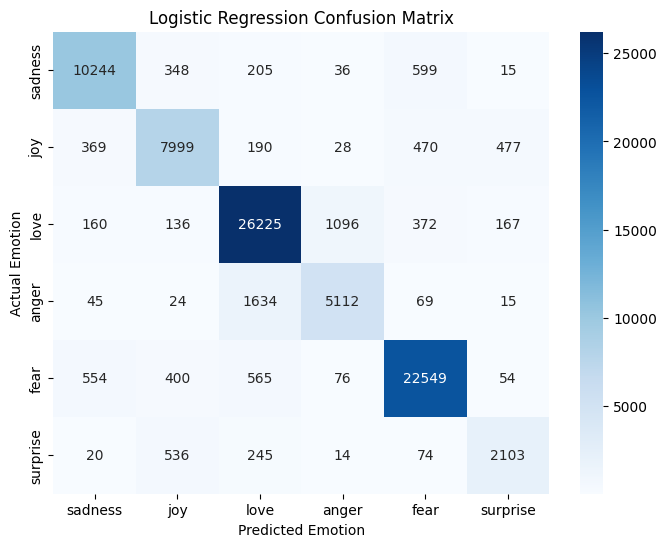

In [43]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Create confusion matrix for Logistic Regression
cm = confusion_matrix(y_test, y_pred_lr)

# Plot confusion matrix
plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,                 # show numbers inside boxes
    fmt='d',                    # integer format
    cmap='Blues',               # color theme
    xticklabels=label_names.values(),
    yticklabels=label_names.values()
)

# Labels and title
plt.xlabel("Predicted Emotion")
plt.ylabel("Actual Emotion")
plt.title("Logistic Regression Confusion Matrix")

plt.show()

# Naive Bayes

In [44]:
from sklearn.naive_bayes import MultinomialNB

# create Naive Bayes model
nb_model = MultinomialNB()

# train the model
nb_model.fit(X_train, y_train)

MultinomialNB()

In [45]:
y_pred_nb = nb_model.predict(X_test)

In [46]:
from sklearn.metrics import accuracy_score

print("Accuracy:", accuracy_score(y_test, y_pred_nb))

Accuracy: 0.7697086212075699


In [47]:
from sklearn.metrics import f1_score

print("F1 Score:", f1_score(y_test, y_pred_nb, average='weighted'))

F1 Score: 0.7379530707501797


In [48]:
from sklearn.metrics import classification_report

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_nb))


Classification Report:

              precision    recall  f1-score   support

       anger       0.94      0.64      0.76     11447
        fear       0.90      0.50      0.64      9533
         joy       0.71      0.97      0.82     28156
        love       0.95      0.23      0.37      6899
     sadness       0.77      0.94      0.84     24198
    surprise       0.97      0.08      0.15      2992

    accuracy                           0.77     83225
   macro avg       0.87      0.56      0.60     83225
weighted avg       0.81      0.77      0.74     83225



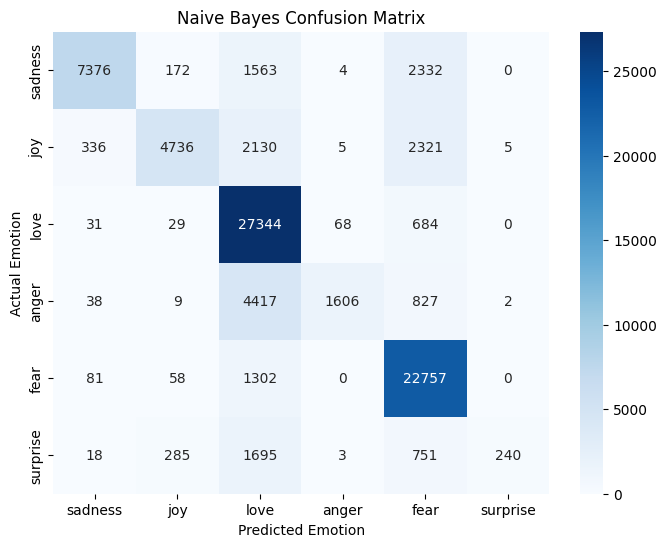

In [49]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Predict using Naive Bayes model
nb_pred = nb_model.predict(X_test)

# Create confusion matrix
cm_nb = confusion_matrix(y_test, y_pred_nb)

# Plot confusion matrix
plt.figure(figsize=(8,6))

sns.heatmap(
    cm_nb,
    annot=True,                 # show numbers inside boxes
    fmt='d',                    # integer format
    cmap='Blues',               # color theme
    xticklabels=label_names.values(),
    yticklabels=label_names.values()
)

# Labels and title
plt.xlabel("Predicted Emotion")
plt.ylabel("Actual Emotion")
plt.title("Naive Bayes Confusion Matrix")

plt.show()

# **Model Comparison**

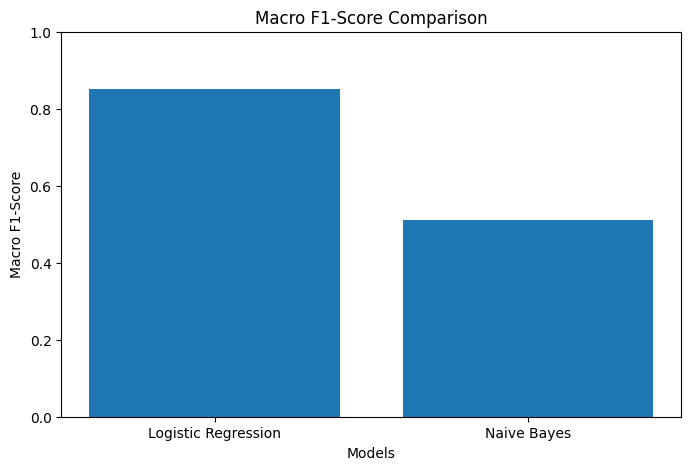

In [50]:
import matplotlib.pyplot as plt

# Model names
models = ['Logistic Regression', 'Naive Bayes']

# Macro F1-scores
scores = [0.85, 0.51]   # replace with your actual macro avg f1-scores

# Create bar graph
plt.figure(figsize=(8,5))

plt.bar(models, scores)

# Labels and title
plt.xlabel("Models")
plt.ylabel("Macro F1-Score")
plt.title("Macro F1-Score Comparison")

# Limit y-axis from 0 to 1
plt.ylim(0, 1)

plt.show()

# **Testing**

In [51]:
# function to predict emotion from a new sentence
def predict_emotion(sentence):

    # Step 1: clean the sentence (lowercase + remove symbols)
    sentence = clean_text(sentence)

    # Step 2: remove stopwords (common useless words)
    sentence = remove_stopwords(sentence)

    # Step 3: convert sentence to TF-IDF format (numbers)
    sentence_vector = tfidf.transform([sentence])

    # Step 4: use trained Logistic Regression model to predict
    predicted_emotion = lr_model.predict(sentence_vector)

    # Step 5: return the predicted emotion
    return predicted_emotion[0]

In [54]:
user_sentence = input("Enter a sentence: ")

emotion = predict_emotion(user_sentence)

print("Predicted Emotion:", emotion)

Enter a sentence: Something about walking through that empty building made me feel like I shouldn’t be there
Predicted Emotion: fear
